# GNN Stability Analysis: Baseline Results
## Cora Dataset - Edge Perturbation Experiments

**Author:** Sileshi Hirpa  
**Supervisor:** Professor He  
**Date:** June 1, 2026  

This notebook analyzes the baseline GCN stability experiments on the Cora dataset under varying levels of edge perturbation.

## 1. Setup: imports and constants

In [1]:
# Cell 1: Setup

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Project constants
PERTURBATION_LEVELS = [0, 5, 10, 20]
N_SEEDS = 5

RESULTS_PATH = Path("../results/local_stability_metrics.json")
FIGURES_PATH = Path("../results/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Results path: {RESULTS_PATH}")
print(f"Figures path: {FIGURES_PATH}")

Setup complete.
Results path: ../results/local_stability_metrics.json
Figures path: ../results/figures


## 2. Load current experiment results

In [2]:
#  Load current experiment results

with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

mean_test_accs = []
std_test_accs = []
raw_scores_by_level = {}

for p in PERTURBATION_LEVELS:
    key = f"perturbation_{p}pct"
    mean_test_accs.append(results[key]["mean_accuracy"])
    std_test_accs.append(results[key]["std_deviation"])
    raw_scores_by_level[p] = results[key]["raw_scores"]

mean_test_pct = np.array(mean_test_accs) * 100
std_test_pct = np.array(std_test_accs) * 100

baseline_pct = mean_test_pct[0]
absolute_drop_pct = mean_test_pct - baseline_pct
relative_drop_pct = ((mean_test_pct - baseline_pct) / baseline_pct) * 100

print("Loaded results successfully.")
print(f"Perturbation levels: {PERTURBATION_LEVELS}")
print(f"Mean test accuracy: {[f'{x:.2f}%' for x in mean_test_pct]}")
print(f"Std dev: {[f'±{x:.2f}%' for x in std_test_pct]}")

Loaded results successfully.
Perturbation levels: [0, 5, 10, 20]
Mean test accuracy: ['79.70%', '79.46%', '78.72%', '77.94%']
Std dev: ['±0.45%', '±0.63%', '±0.92%', '±0.59%']


## Interpretation: Loading Current Experiment Results

This cell loads the saved GCN stability experiment results from `RESULTS_PATH`, which points to the current JSON file:

```python
../results/local_stability_metrics.json



> Main Interpretation

The results show a gradual decrease in GCN test accuracy as more edges are removed from the Cora graph. The baseline model, with no edge deletion, reaches 79.70% test accuracy. At 20% edge deletion, accuracy drops to 77.94%.

This suggests that the GCN model is sensitive to changes in graph structure, but the decrease is not severe at the perturbation levels tested so far. The largest variation across random seeds appears at 10% edge deletion, where the standard deviation reaches ±0.92%. This may indicate that the model is especially sensitive to which specific edges are removed around that perturbation level.

At this stage, the result should be treated as an early stability observation rather than a final conclusion. More seeds, finer perturbation levels, and validation accuracy tracking will be needed in the next version of the experiment.

## 3. Summary statistics table

In [3]:
# Summary table

summary_df = pd.DataFrame({
    "Perturbation Level": [f"{p}%" for p in PERTURBATION_LEVELS],
    "Mean Test Accuracy": [f"{x:.2f}%" for x in mean_test_pct],
    "Std Dev": [f"±{x:.2f}%" for x in std_test_pct],
    "Absolute Drop": [f"{x:.2f}%" for x in absolute_drop_pct],
    "Relative Drop": [f"{x:.2f}%" for x in relative_drop_pct],
})

display(summary_df)

,Perturbation Level,Mean Test Accuracy,Std Dev,Absolute Drop,Relative Drop
0,0%,79.70%,±0.45%,0.00%,0.00%
1,5%,79.46%,±0.63%,-0.24%,-0.30%
2,10%,78.72%,±0.92%,-0.98%,-1.23%
3,20%,77.94%,±0.59%,-1.76%,-2.21%


In [4]:
#  Export markdown table for README

print("\n=== Markdown Table for README ===")
print("| Perturbation Level | Mean Test Accuracy | Std Dev | Absolute Drop | Relative Drop |")
print("|---|---:|---:|---:|---:|")

for i, p in enumerate(PERTURBATION_LEVELS):
    print(
        f"| {p}% | "
        f"{mean_test_pct[i]:.2f}% | "
        f"±{std_test_pct[i]:.2f}% | "
        f"{absolute_drop_pct[i]:.2f}% | "
        f"{relative_drop_pct[i]:.2f}% |"
    )


=== Markdown Table for README ===
| Perturbation Level | Mean Test Accuracy | Std Dev | Absolute Drop | Relative Drop |
|---|---:|---:|---:|---:|
| 0% | 79.70% | ±0.45% | 0.00% | 0.00% |
| 5% | 79.46% | ±0.63% | -0.24% | -0.30% |
| 10% | 78.72% | ±0.92% | -0.98% | -1.23% |
| 20% | 77.94% | ±0.59% | -1.76% | -2.21% |


## Interpretation: Summary Statistics Table

This table gives a compact view of the first GCN stability results on the Cora dataset. It shows that test accuracy gradually decreases as more graph edges are removed.

The baseline accuracy is **79.70%** with no edge deletion. At **20% edge deletion**, accuracy drops to **77.94%**, which is an absolute decrease of **1.76 percentage points** and a relative decrease of about **2.21%**.

The largest standard deviation appears at **10% edge deletion**. This suggests that the model may be more sensitive to which specific edges are removed at that level.

Overall, the table supports an early stability observation: the GCN is affected by graph perturbation, but the decline is moderate in this initial experiment.

## 4. Perturbation curve

> What happens to average GCN accuracy as more edges are deleted?

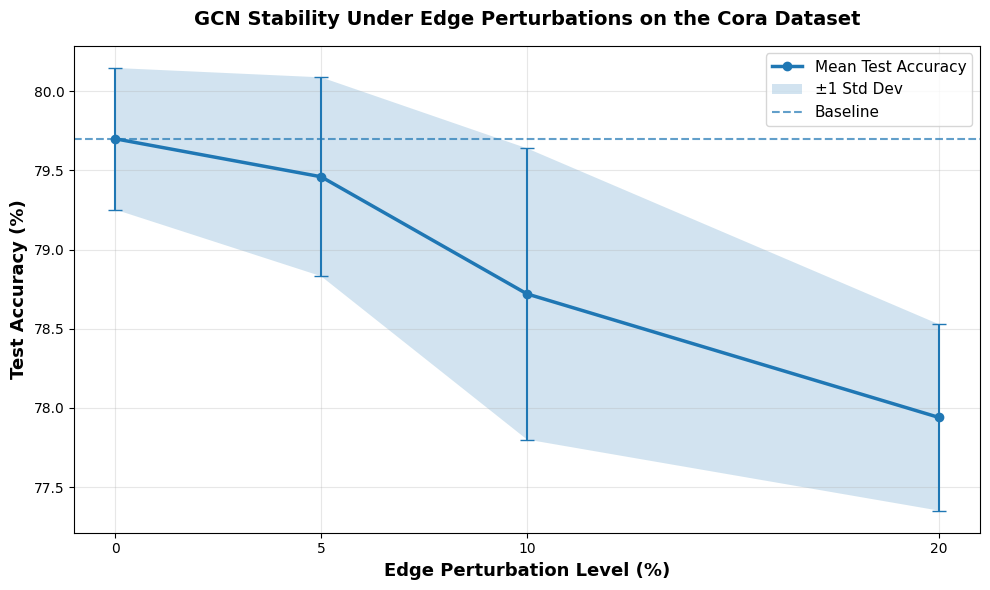

In [5]:
# Perturbation curve with error bars and shaded band

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    PERTURBATION_LEVELS,
    mean_test_pct,
    marker="o",
    linewidth=2.5,
    label="Mean Test Accuracy"
)

ax.fill_between(
    PERTURBATION_LEVELS,
    mean_test_pct - std_test_pct,
    mean_test_pct + std_test_pct,
    alpha=0.2,
    label="±1 Std Dev"
)

ax.errorbar(
    PERTURBATION_LEVELS,
    mean_test_pct,
    yerr=std_test_pct,
    fmt="none",
    capsize=5
)

ax.axhline(
    y=baseline_pct,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Baseline"
)

ax.set_xlabel("Edge Perturbation Level (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "GCN Stability Under Edge Perturbations on the Cora Dataset",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xticks(PERTURBATION_LEVELS)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "perturbation_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation: Perturbation Curve

This figure shows the main stability trend for the GCN model on the Cora dataset. As the edge perturbation level increases, the mean test accuracy gradually decreases.

The baseline accuracy is **79.70%** with no edge deletion. At **20% edge deletion**, the accuracy drops to **77.94%**. This is a moderate decline, not a severe collapse.

The shaded region and error bars show variation across the five random seed runs. The wider band around **10% perturbation** suggests that the model is more sensitive to which specific edges are removed at that level.

Overall, this plot supports the early finding that GCN performance depends on graph structure, but the model remains reasonably stable under the perturbation levels tested so far.

## 5. Variance analysis

> At which perturbation level does the model become more variable?

✅ Saved figure to: results/figures/variance_analysis.png


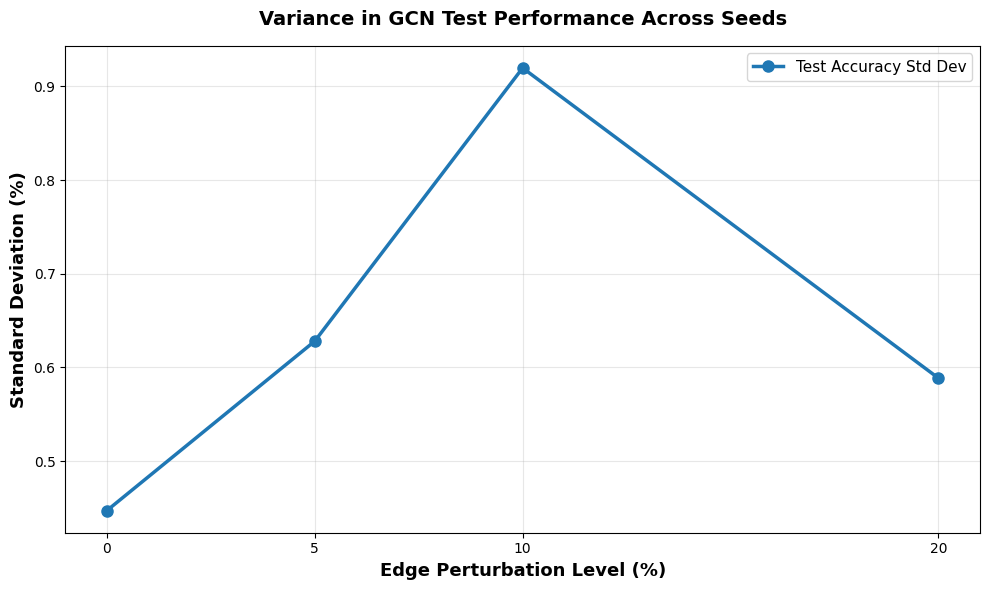

In [6]:
#  Variance Analysis

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    PERTURBATION_LEVELS,
    std_test_pct,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label="Test Accuracy Std Dev"
)

ax.set_xlabel("Edge Perturbation Level (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Standard Deviation (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "Variance in GCN Test Performance Across Seeds",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(PERTURBATION_LEVELS)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "variance_analysis.png", dpi=300, bbox_inches="tight")
print("✅ Saved figure to: results/figures/variance_analysis.png")

plt.show()

## Interpretation: Variance Analysis

This figure shows how much the GCN test accuracy varies across the five random seed runs at each edge perturbation level.

The standard deviation increases from **±0.45%** at 0% perturbation to **±0.92%** at 10% perturbation. This suggests that around **10% edge deletion**, the model becomes more sensitive to which specific edges are removed.

At 20% perturbation, the standard deviation drops to **±0.59%**, even though the mean accuracy continues to decline. This may suggest that stronger perturbation produces a more consistently degraded graph structure.

Overall, the variance plot supports the idea that instability is not only about lower accuracy. It is also about how much the result changes across different random perturbations.

## 6. Raw seed score distribution

> Are the mean and standard deviation hiding anything unusual?

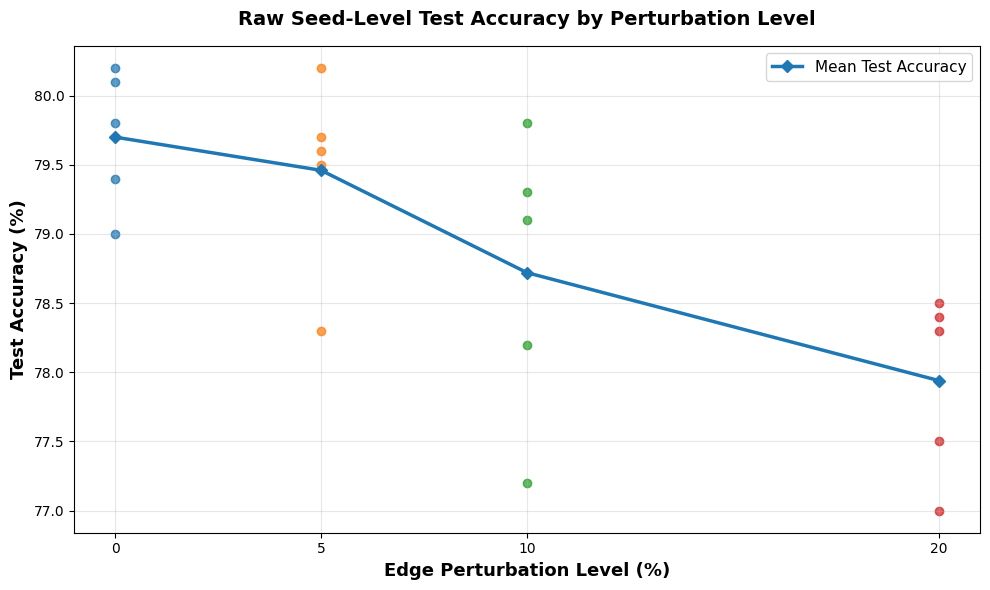

In [7]:
# Raw seed score distribution by perturbation level

fig, ax = plt.subplots(figsize=(10, 6))

for p in PERTURBATION_LEVELS:
    scores_pct = np.array(raw_scores_by_level[p]) * 100
    x_positions = np.full(len(scores_pct), p)
    ax.scatter(x_positions, scores_pct, alpha=0.75)

ax.plot(
    PERTURBATION_LEVELS,
    mean_test_pct,
    marker="D",
    linewidth=2.5,
    label="Mean Test Accuracy"
)

ax.set_xlabel("Edge Perturbation Level (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "Raw Seed-Level Test Accuracy by Perturbation Level",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xticks(PERTURBATION_LEVELS)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "raw_seed_scores.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation: Raw Seed Score Distribution

This figure shows the individual test accuracy scores from the five random seed runs at each perturbation level. It provides a closer look at the raw results behind the mean accuracy line.

The plot confirms the same general pattern seen earlier: test accuracy gradually decreases as more graph edges are removed. At **0%** and **5%** perturbation, most seed results remain close to the baseline range. At **10%** perturbation, the spread becomes wider, showing greater variation across seeds. At **20%** perturbation, the scores are generally lower, confirming the overall decline in model performance.

This plot is useful because it shows that the average trend is not hiding the seed-level behavior. The model does not fail suddenly, but its performance becomes more variable as the graph structure is perturbed.

## 7. Individual seed performance trajectories

> Does each seed follow the same downward pattern, or do some seeds behave differently?

✅ Saved figure to: results/figures/seed_trajectories.png


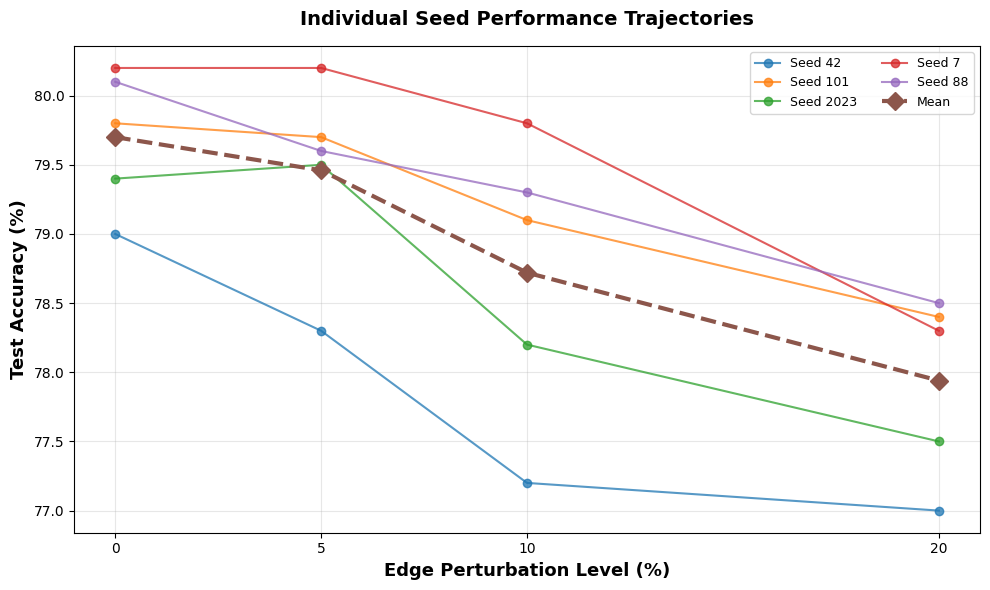

In [8]:
# Cell 7: Individual Seed Performance Trajectories

# Seeds used in local_stability_test.py
SEEDS = [42, 101, 2023, 7, 88]

# Build seed-level trajectories from raw_scores
seed_data = {seed: [] for seed in SEEDS}

for p in PERTURBATION_LEVELS:
    key = f"perturbation_{p}pct"
    raw_scores = results[key]["raw_scores"]
    
    for idx, seed in enumerate(SEEDS):
        seed_data[seed].append(raw_scores[idx] * 100)

# Plot individual seed trajectories
fig, ax = plt.subplots(figsize=(10, 6))

for seed in SEEDS:
    ax.plot(
        PERTURBATION_LEVELS,
        seed_data[seed],
        marker="o",
        linewidth=1.5,
        alpha=0.75,
        label=f"Seed {seed}"
    )

# Add mean line
ax.plot(
    PERTURBATION_LEVELS,
    mean_test_pct,
    marker="D",
    markersize=9,
    linewidth=3,
    label="Mean",
    linestyle="--"
)

ax.set_xlabel("Edge Perturbation Level (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "Individual Seed Performance Trajectories",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(PERTURBATION_LEVELS)

plt.tight_layout()

plt.savefig(FIGURES_PATH / "seed_trajectories.png", dpi=300, bbox_inches="tight")
print("✅ Saved figure to: results/figures/seed_trajectories.png")

plt.show()

## Interpretation: Individual Seed Performance Trajectories

This figure shows how each random seed performs as the edge perturbation level increases. The dashed mean line confirms the overall downward trend in test accuracy.

Most seeds follow a similar pattern: accuracy decreases as more graph edges are removed. This supports the idea that the observed performance decline is not caused by only one unusual seed run.

Seed 42 appears consistently lower than the others, while Seed 7 and Seed 88 remain stronger at lower perturbation levels. By 20% edge deletion, the seed results are closer together, suggesting a more uniformly degraded performance level.

Overall, this plot supports the early stability finding: the GCN model does not fail suddenly, but its performance gradually weakens as the graph structure becomes more disrupted.

## 8. Key Observations

### Performance Degradation

The GCN model shows a gradual decline in test accuracy as edge deletion increases:

- Baseline, 0% perturbation: **79.70% ± 0.45%**
- 5% edge deletion: **79.46% ± 0.63%**, Δ = **-0.24%**
- 10% edge deletion: **78.72% ± 0.92%**, Δ = **-0.98%**
- 20% edge deletion: **77.94% ± 0.59%**, Δ = **-1.76%**

This suggests that the GCN model is sensitive to graph structure perturbation, but the decline is gradual rather than catastrophic in this initial experiment.

### Variance Across Seeds

The largest standard deviation appears at **10% edge deletion** with **±0.92%**. This suggests that the specific random edges removed can affect the model’s performance.

The standard deviation drops slightly at 20%, which may indicate that stronger perturbation produces a more uniformly degraded graph structure. This interpretation should be treated as preliminary until more perturbation levels and more seeds are tested.

### Current Limitation

The current experiment only logs test accuracy across five random seeds. Training accuracy, validation accuracy, loss curves, and runtime are not yet included.

These will be added in a later version of `local_stability_test.py`.


## 9. Next Steps

For the next stage, the project should focus on improving the experimental pipeline before moving to advanced theory.

Recommended next steps:

1. Add training and validation accuracy tracking to `local_stability_test.py`.
2. Add runtime and hyperparameter logging.
3. Add finer perturbation levels, such as 2.5%, 7.5%, and 15%.
4. Rerun experiments with more seeds for stronger reliability.
5. Begin short literature notes on GNN stability and robustness.
6. Later-stage work may include spectral analysis, empirical Lipschitz measurements, GAT comparison, and Sol cluster deployment.

## 10. Export Summary for README

In [9]:
# Export Summary for README

# Create numeric summary table first
readme_summary_df = pd.DataFrame({
    "Perturbation Level (%)": PERTURBATION_LEVELS,
    "Mean Test Accuracy (%)": mean_test_pct,
    "Std Dev (%)": std_test_pct,
    "Absolute Drop (%)": mean_test_pct - mean_test_pct[0],
    "Relative Drop (%)": ((mean_test_pct - mean_test_pct[0]) / mean_test_pct[0]) * 100
})

# Display a professional styled table in Jupyter
styled_summary = (
    readme_summary_df.style
    .format({
        "Perturbation Level (%)": "{:.0f}",
        "Mean Test Accuracy (%)": "{:.2f}",
        "Std Dev (%)": "±{:.2f}",
        "Absolute Drop (%)": "{:.2f}",
        "Relative Drop (%)": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption("GCN Stability Summary Under Edge Deletion Perturbations")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border-bottom", "2px solid black"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
)

display(styled_summary)

# Print clean markdown table for README without requiring tabulate
print("\n=== Markdown Table for README ===")
print("| Perturbation Level | Mean Test Accuracy | Std Dev | Absolute Drop | Relative Drop |")
print("|---|---:|---:|---:|---:|")

for i, p in enumerate(PERTURBATION_LEVELS):
    absolute_drop = mean_test_pct[i] - mean_test_pct[0]
    relative_drop = (absolute_drop / mean_test_pct[0]) * 100
    
    print(
        f"| {p}% | "
        f"{mean_test_pct[i]:.2f}% | "
        f"±{std_test_pct[i]:.2f}% | "
        f"{absolute_drop:.2f}% | "
        f"{relative_drop:.2f}% |"
    )

Perturbation Level (%),Mean Test Accuracy (%),Std Dev (%),Absolute Drop (%),Relative Drop (%)
0,79.70,±0.45,0.00,0.00
5,79.46,±0.63,-0.24,-0.30
10,78.72,±0.92,-0.98,-1.23
20,77.94,±0.59,-1.76,-2.21



=== Markdown Table for README ===
| Perturbation Level | Mean Test Accuracy | Std Dev | Absolute Drop | Relative Drop |
|---|---:|---:|---:|---:|
| 0% | 79.70% | ±0.45% | 0.00% | 0.00% |
| 5% | 79.46% | ±0.63% | -0.24% | -0.30% |
| 10% | 78.72% | ±0.92% | -0.98% | -1.23% |
| 20% | 77.94% | ±0.59% | -1.76% | -2.21% |
